Project Title: Smart Mobility & Ride Analytics

Problem Statement:

Analyze a real-world ride-hailing business dataset using concepts from Mathematics for Data Science, Probability, Statistics, and Hypothesis Testing.
Your goal is to uncover operational insights, validate assumptions, and support decision-making using analytical methods.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    ttest_1samp,
    chi2_contingency,
    f_oneway,
    norm,
    zscore
)
import warnings
warnings.filterwarnings("ignore")

* Prepare and clean the dataset using NumPy and Pandas

In [3]:
df = pd.read_excel("Trip_Analysis.xlsx")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (200, 6)


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()
# Handle missing values
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Cleaning completed!")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Cleaning completed!

Missing values after cleaning:
Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64


* Apply Linear Algebra concepts (vectors, matrices, determinant, eigenvalues/eigenvectors)

In [5]:
# Create feature vector using mean values
vector = np.array([
    df["Trip_Distance"].mean(),
    df["Fare_Amount"].mean(),
    df["Surge_Multiplier"].mean(),
    df["Customer_Rating"].mean()
])
print("Feature Vector:")
print(vector)
print("\nVector Shape:", vector.shape)
print("\nVector Magnitude:")
print(np.linalg.norm(vector))

Feature Vector:
[ 15.64     260.312376   1.6775     2.93    ]

Vector Shape: (4,)

Vector Magnitude:
260.8036456940847


In [6]:
# Numerical columns
num_cols = [
    "Trip_Distance",
    "Fare_Amount",
    "Surge_Multiplier",
    "Customer_Rating"
]
# Correlation matrix as a mathematical matrix
matrix = df[num_cols].corr().values
print("Correlation Matrix:")
print(matrix)
print("\nMatrix Shape:")
print(matrix.shape)

Correlation Matrix:
[[ 1.          0.01681311  0.01713074 -0.08459862]
 [ 0.01681311  1.          0.01741939  0.05272279]
 [ 0.01713074  0.01741939  1.         -0.04130378]
 [-0.08459862  0.05272279 -0.04130378  1.        ]]

Matrix Shape:
(4, 4)


In [7]:
# Determinant
determinant = np.linalg.det(matrix)
print("Determinant of correlation matrix:")
print(determinant)

Determinant of correlation matrix:
0.9873870430672445


In [8]:
# Eigenvalue and Eigenvector analysis
eigenvalues, eigenvectors = np.linalg.eig(matrix)
print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[0.88618284 1.1055071  0.98266344 1.02564662]

Eigenvectors:
[[-0.53777588  0.58844968  0.5492467   0.25070326]
 [ 0.43248566 -0.20303316  0.25762521  0.83985888]
 [-0.2337979   0.33830171 -0.79495255  0.44602795]
 [-0.68490276 -0.70573115  0.00278261  0.18122917]]


* Use Probability concepts (basic probability, conditional probability, Bayes’ theorem, distributions)

In [9]:
# Total number of rides
total_rides = len(df)
print("Total Rides:", total_rides)
# Ride category counts
category_counts = df["Ride_Category"].value_counts()
print("\nRide Category Counts:")
print(category_counts)
# Basic probability of each ride category
print("\nBasic Probability:")
for category, count in category_counts.items():
    probability = count / total_rides
    print(
        f"P({category}) = {probability:.4f}"
    )

Total Rides: 200

Ride Category Counts:
Ride_Category
Economy    82
Shared     60
Premium    58
Name: count, dtype: int64

Basic Probability:
P(Economy) = 0.4100
P(Shared) = 0.3000
P(Premium) = 0.2900


In [10]:
# Total Peak rides
peak_rides = len(
    df[df["Ride_Time"] == "Peak"]
)
# Premium rides during Peak
premium_peak_rides = len(
    df[
        (df["Ride_Time"] == "Peak") &
        (df["Ride_Category"] == "Premium")
    ]
)
# Conditional probability
P_premium_given_peak = (
    premium_peak_rides / peak_rides
)
print("Total Peak Rides:", peak_rides)
print("Premium Peak Rides:", premium_peak_rides)
print(
    "\nP(Premium | Peak) =",
    round(P_premium_given_peak, 4)
)

Total Peak Rides: 103
Premium Peak Rides: 32

P(Premium | Peak) = 0.3107


In [11]:
# P(Premium)
P_premium = (
    df["Ride_Category"] == "Premium"
).mean()
# P(Peak)
P_peak = (
    df["Ride_Time"] == "Peak"
).mean()
# P(Peak | Premium)
premium_total = len(
    df[df["Ride_Category"] == "Premium"]
)
premium_peak = len(
    df[
        (df["Ride_Category"] == "Premium") &
        (df["Ride_Time"] == "Peak")
    ]
)
P_peak_given_premium = (
    premium_peak / premium_total
)
# Bayes theorem
P_premium_given_peak_bayes = (
    P_peak_given_premium * P_premium
) / P_peak
print("P(Premium) =", round(P_premium, 4))
print("P(Peak) =", round(P_peak, 4))
print(
    "P(Peak | Premium) =",
    round(P_peak_given_premium, 4)
)
print(
    "\nUsing Bayes' Theorem:"
)
print(
    "P(Premium | Peak) =",
    round(P_premium_given_peak_bayes, 4)
)

P(Premium) = 0.29
P(Peak) = 0.515
P(Peak | Premium) = 0.5517

Using Bayes' Theorem:
P(Premium | Peak) = 0.3107


In [12]:
probability_distribution = (
    df["Ride_Category"]
    .value_counts(normalize=True)
)
print("Ride Category Probability Distribution:")
print(probability_distribution)
# Convert into percentage
percentage_distribution = (
    probability_distribution * 100
)
print("\nPercentage Distribution:")
print(percentage_distribution)

Ride Category Probability Distribution:
Ride_Category
Economy    0.41
Shared     0.30
Premium    0.29
Name: proportion, dtype: float64

Percentage Distribution:
Ride_Category
Economy    41.0
Shared     30.0
Premium    29.0
Name: proportion, dtype: float64


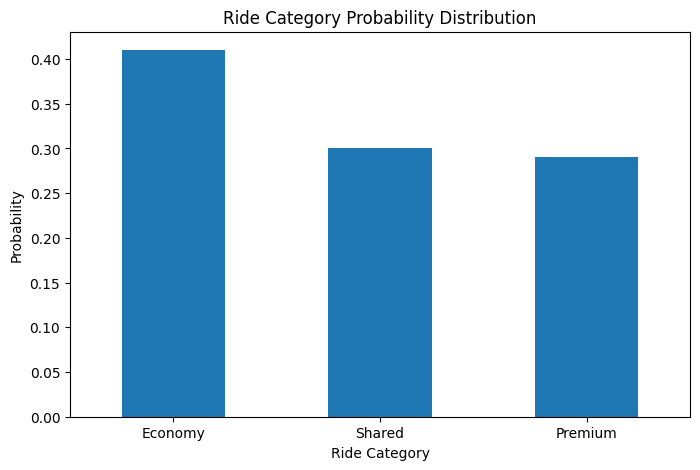

In [13]:
plt.figure(figsize=(8,5))
probability_distribution.plot(
    kind="bar"
)
plt.title("Ride Category Probability Distribution")
plt.xlabel("Ride Category")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.show()

Ride Time Probability Distribution:
Ride_Time
Peak        0.515
Non-Peak    0.485
Name: proportion, dtype: float64


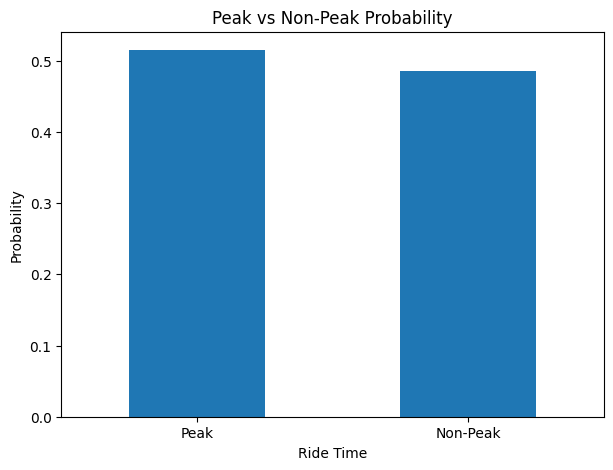

In [14]:
# Probability of Peak and Non-Peak rides

ride_time_probability = (
    df["Ride_Time"]
    .value_counts(normalize=True)
)

print("Ride Time Probability Distribution:")
print(ride_time_probability)

plt.figure(figsize=(7,5))

ride_time_probability.plot(
    kind="bar"
)

plt.title("Peak vs Non-Peak Probability")
plt.xlabel("Ride Time")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.show()

* Perform Descriptive Statistics (mean, median, mode, variance, standard deviation, skewness, kurtosis)

In [15]:
numeric_columns = [
    "Trip_Distance",
    "Fare_Amount",
    "Surge_Multiplier",
    "Customer_Rating"
]
for col in numeric_columns:
    print("\n" + "="*50)
    print(col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode().iloc[0])
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


Trip_Distance
Mean: 15.64
Median: 15.0
Mode: 29
Variance: 71.12603015075378
Standard Deviation: 8.433624970957256
Skewness: 0.05281707931271716
Kurtosis: -1.2701490849807193

Fare_Amount
Mean: 260.31237600443757
Median: 256.90710336367647
Mode: 37.58591619492239
Variance: 6194.6544681141895
Standard Deviation: 78.70612725902723
Skewness: 0.02283672487999021
Kurtosis: -0.2514301368584819

Surge_Multiplier
Mean: 1.6775
Median: 1.5
Mode: 1.0
Variance: 0.3012500000000002
Standard Deviation: 0.5488624600025039
Skewness: 0.15606704382062128
Kurtosis: -1.2953992816112225

Customer_Rating
Mean: 2.93
Median: 3.0
Mode: 1
Variance: 2.0855276381909538
Standard Deviation: 1.4441356024248393
Skewness: 0.06273311362341241
Kurtosis: -1.3237238320761193


In [16]:
stats_table = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Variance": df[numeric_columns].var(),
    "Std_Deviation": df[numeric_columns].std(),
    "Skewness": df[numeric_columns].skew(),
    "Kurtosis": df[numeric_columns].kurt()
})
display(stats_table)

,Mean,Median,Mode,Variance,Std_Deviation,Skewness,Kurtosis
Trip_Distance,15.640000,15.000000,29.000000,71.126030,8.433625,0.052817,-1.270149
Fare_Amount,260.312376,256.907103,37.585916,6194.654468,78.706127,0.022837,-0.251430
Surge_Multiplier,1.677500,1.500000,1.000000,0.301250,0.548862,0.156067,-1.295399
Customer_Rating,2.930000,3.000000,1.000000,2.085528,1.444136,0.062733,-1.323724


* Detect outliers using percentiles, quartiles, IQR, and z-score

In [22]:
# Select the column
data = df["Fare_Amount"]
# 1. PERCENTILES
p10 = np.percentile(data, 10)
p25 = np.percentile(data, 25)
p50 = np.percentile(data, 50)
p75 = np.percentile(data, 75)
p90 = np.percentile(data, 90)
p95 = np.percentile(data, 95)
print("PERCENTILES")
print("-" * 40)
print("10th Percentile :", p10)
print("25th Percentile :", p25)
print("50th Percentile :", p50)
print("75th Percentile :", p75)
print("90th Percentile :", p90)
print("95th Percentile :", p95)

PERCENTILES
----------------------------------------
10th Percentile : 157.99441144712605
25th Percentile : 208.5288261048614
50th Percentile : 256.90710336367647
75th Percentile : 319.7637824819526
90th Percentile : 359.83011044895943
95th Percentile : 383.0853513409336


In [23]:
# 2. QUARTILES
Q1 = data.quantile(0.25)
Q2 = data.quantile(0.50)
Q3 = data.quantile(0.75)
print("\nQUARTILES")
print("-" * 40)
print("Q1 :", Q1)
print("Q2 / Median :", Q2)
print("Q3 :", Q3)


QUARTILES
----------------------------------------
Q1 : 208.5288261048614
Q2 / Median : 256.90710336367647
Q3 : 319.7637824819526


In [24]:
# 3. IQR METHOD
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nIQR METHOD")
print("-" * 40)
print("IQR :", IQR)
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)
# Detect IQR outliers
iqr_outliers = df[
    (df[column] < lower_bound) |
    (df[column] > upper_bound)
]
print("\nNumber of IQR Outliers :", len(iqr_outliers))
display(iqr_outliers)


IQR METHOD
----------------------------------------
IQR : 111.23495637709121
Lower Bound : 41.67639153922457
Upper Bound : 486.61621704758943

Number of IQR Outliers : 1


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
10,12,37.585916,Economy,1.0,5,Non-Peak


In [25]:
# 4. Z-SCORE METHOD
z_scores = np.abs(stats.zscore(data))
# Z-score > 3 considered an outlier
z_outlier_index = data.index[z_scores > 3]
z_outliers = df.loc[z_outlier_index]
print("\nZ-SCORE METHOD")
print("-" * 40)
print("Z-score threshold : ±3")
print("Number of Z-score Outliers :", len(z_outliers))
display(z_outliers)



Z-SCORE METHOD
----------------------------------------
Z-score threshold : ±3
Number of Z-score Outliers : 0


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time


In [26]:
# 5. SUMMARY
print("\nOUTLIER SUMMARY")
print("-" * 40)
print("IQR Outliers     :", len(iqr_outliers))
print("Z-Score Outliers :", len(z_outliers))


OUTLIER SUMMARY
----------------------------------------
IQR Outliers     : 1
Z-Score Outliers : 0


* Measure relationships using Pearson, Spearman, and covariance

In [27]:
# Pearson Correlation
pearson_corr, pearson_p = pearsonr(
    df["Trip_Distance"],
    df["Fare_Amount"]
)
print("Pearson Correlation")
print("-------------------")
print("Correlation :", pearson_corr)
print("P-value     :", pearson_p)
if pearson_p < 0.05:
    print("Result: Significant linear relationship.")
else:
    print("Result: No significant linear relationship.")

Pearson Correlation
-------------------
Correlation : 0.016813110993310933
P-value     : 0.8132001771984599
Result: No significant linear relationship.


In [28]:
# Spearman Correlation
spearman_corr, spearman_p = spearmanr(
    df["Surge_Multiplier"],
    df["Customer_Rating"]
)
print("Spearman Correlation")
print("--------------------")
print("Correlation :", spearman_corr)
print("P-value     :", spearman_p)
if spearman_p < 0.05:
    print("Result: Significant relationship.")
else:
    print("Result: No significant relationship.")

Spearman Correlation
--------------------
Correlation : -0.04709083768799108
P-value     : 0.5078698477562074
Result: No significant relationship.


In [29]:
# Covariance
covariance = df[
    ["Trip_Distance", "Fare_Amount"]
].cov()
print("Covariance Matrix")
print("-----------------")
display(covariance)

Covariance Matrix
-----------------


,Trip_Distance,Fare_Amount
Trip_Distance,71.126030,11.160173
Fare_Amount,11.160173,6194.654468


In [30]:
#Individual covariance
cov_value = df["Trip_Distance"].cov(
    df["Fare_Amount"]
)
print("Covariance between Trip Distance and Fare Amount:")
print(cov_value)

Covariance between Trip Distance and Fare Amount:
11.160172520076761


* Apply Inferential Statistics (bootstrapping, CLT, point & interval estimation)

In [31]:
# Fare Amount
data = df["Fare_Amount"].dropna()
# 1. Point Estimation
mean = data.mean()
print("Point Estimate (Mean):", mean)
# 2. Interval Estimation - 95% CI
n = len(data)
se = data.std() / np.sqrt(n)
ci = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=se
)
print("95% Confidence Interval:", ci)
# 3. CLT
sample_means = []
for i in range(1000):
    sample = np.random.choice(data, 30, replace=True)
    sample_means.append(sample.mean())
print("CLT Mean of Sample Means:",
      np.mean(sample_means))
# 4. Bootstrapping
bootstrap_means = []
for i in range(1000):
    sample = np.random.choice(
        data,
        len(data),
        replace=True
    )
    bootstrap_means.append(sample.mean())
bootstrap_ci = np.percentile(
    bootstrap_means,
    [2.5, 97.5]
)
print("Bootstrap 95% CI:",
      bootstrap_ci)

Point Estimate (Mean): 260.31237600443757
95% Confidence Interval: (np.float64(249.33772077198984), np.float64(271.2870312368853))
CLT Mean of Sample Means: 260.0447482629501
Bootstrap 95% CI: [248.86781051 271.42053144]


* Conduct Hypothesis Testing (z-test, t-test, chi-square, F-test, ANOVA, A/B testing)

In [35]:
alpha = 0.05
# 1. Z-Test
fare = df["Fare_Amount"].dropna()
z = (fare.mean() - 50) / (fare.std() / np.sqrt(len(fare)))
p = 2 * (1 - stats.norm.cdf(abs(z)))
print("Z-Test:", z, p)
# 2. T-Test
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]
economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]
t, p = stats.ttest_ind(premium, economy, equal_var=False)
print("T-Test:", t, p)
# 3. Chi-Square Test
table = pd.crosstab(
    df["Ride_Category"],
    df["Ride_Time"]
)
chi, p, dof, expected = stats.chi2_contingency(table)
print("Chi-Square:", chi, p)
# 4. F-Test
F = premium.var() / economy.var()
print("F-Test:", F)
# 5. ANOVA
groups = [
    group["Fare_Amount"]
    for name, group in df.groupby("Ride_Category")
]
F, p = stats.f_oneway(*groups)
print("ANOVA:", F, p)
# 6. A/B Testing
peak = df[df["Ride_Time"] == "Peak"]["Fare_Amount"]
non_peak = df[df["Ride_Time"] == "Non-Peak"]["Fare_Amount"]
t, p = stats.ttest_ind(
    peak,
    non_peak,
    equal_var=False
)
print("A/B Test:", t, p)

Z-Test: 37.78951205432002 0.0
T-Test: -0.40600606266641986 0.6854530831483114
Chi-Square: 1.4810469877052506 0.4768642146833866
F-Test: 1.0405395155977981
ANOVA: 0.9284988792342401 0.3968686165946833
A/B Test: -0.596491792388811 0.5515482990013166


# Analysis Questions:

1. Does trip distance significantly affect fare amount? (Hint: Use Pearson correlation, covariance, and linear algebra interpretation.)

In [36]:
x = df["Trip_Distance"]
y = df["Fare_Amount"]
# Pearson Correlation
pearson, p_value = pearsonr(x, y)
# Covariance
covariance = x.cov(y)
# Linear Algebra - Dot Product
dot_product = np.dot(x, y)
print("Pearson Correlation:", pearson)
print("P-value:", p_value)
print("Covariance:", covariance)
print("Dot Product:", dot_product)
if p_value < 0.05:
    print("Trip distance significantly affects fare amount.")
else:
    print("Trip distance does not significantly affect fare amount.")

Pearson Correlation: 0.016813110993310933
P-value: 0.8132001771984599
Covariance: 11.160172520076761
Dot Product: 816477.9864733759
Trip distance does not significantly affect fare amount.


2. Are premium rides statistically more expensive than economy rides? (Hint: Compare groups using t-test / ANOVA and summarize with descriptive statistics.)

In [37]:
# Premium and Economy fares
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"].dropna()
economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"].dropna()
# Descriptive Statistics
print("Premium Rides")
print("Count :", len(premium))
print("Mean  :", premium.mean())
print("Median:", premium.median())
print("Std   :", premium.std())
print("\nEconomy Rides")
print("Count :", len(economy))
print("Mean  :", economy.mean())
print("Median:", economy.median())
print("Std   :", economy.std())
# T-Test
t_stat, p_value = ttest_ind(
    premium,
    economy,
    equal_var=False
)
print("\nT-Test Results")
print("T-statistic:", t_stat)
print("P-value:", p_value)
# Conclusion
if p_value < 0.05 and premium.mean() > economy.mean():
    print("\nConclusion: Premium rides are statistically more expensive than Economy rides.")
elif p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference, but Premium mean fare is not higher.")
else:
    print("\nConclusion: There is no statistically significant difference.")

Premium Rides
Count : 58
Mean  : 252.45503727502648
Median: 250.89798604001987
Std   : 76.61133642833087

Economy Rides
Count : 82
Mean  : 257.74844283796944
Median: 259.13770041494786
Std   : 75.10411787252293

T-Test Results
T-statistic: -0.40600606266641986
P-value: 0.6854530831483114

Conclusion: There is no statistically significant difference.


3. Is there a relationship between surge pricing and customer ratings? (Hint: Use Spearman correlation and test significance statistically.)

In [38]:
x1 = df["Surge_Multiplier"]
y1 = df["Customer_Rating"]

# Spearman Correlation
correlation, p_value = spearmanr(x1, y1)

print("Spearman Correlation:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a statistically significant relationship.")
else:
    print("There is no statistically significant relationship.")

Spearman Correlation: -0.04709083768799108
P-value: 0.5078698477562074
There is no statistically significant relationship.


4. Do peak-hour rides differ in revenue compared to non-peak rides? (Hint: Apply z-test / t-test.)

In [39]:
# Peak and Non-Peak rides
peak = df[df["Ride_Time"].isin(["Peak"])]["Fare_Amount"].dropna()
non_peak = df[df["Ride_Time"].isin(["Non-Peak"])]["Fare_Amount"].dropna()
# Descriptive statistics
print("Peak Hour Mean Revenue:", peak.mean())
print("Non-Peak Mean Revenue:", non_peak.mean())
# Independent t-test
t_stat, p_value = ttest_ind(peak, non_peak, equal_var=False)
print("\nT-statistic:", t_stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("Peak-hour and non-peak-hour revenues are significantly different.")
else:
    print("There is no significant difference in revenue.")

Peak Hour Mean Revenue: 257.0746665038188
Non-Peak Mean Revenue: 263.75035619581627

T-statistic: -0.596491792388811
P-value: 0.5515482990013166
There is no significant difference in revenue.


5. Are there unusual fare values that indicate anomalies or pricing errors? ( Hint: Detect using IQR, z-score, quartiles, and percentiles.)

In [42]:
fare = df["Fare_Amount"].dropna()

# Quartiles
Q1 = fare.quantile(0.25)
Q2 = fare.quantile(0.50)
Q3 = fare.quantile(0.75)

# IQR
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# IQR Outliers
iqr_outliers = fare[(fare < lower) | (fare > upper)]

# Percentiles
print("25th Percentile (Q1):", Q1)
print("50th Percentile (Median):", Q2)
print("75th Percentile (Q3):", Q3)
print("5th Percentile:", np.percentile(fare, 5))
print("95th Percentile:", np.percentile(fare, 95))

print("\nIQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("\nIQR Outliers:", len(iqr_outliers))

# Z-score
z = zscore(fare)
z_outliers = fare[np.abs(z) > 3]

print("Z-score Outliers:", len(z_outliers))

if len(iqr_outliers) > 0 or len(z_outliers) > 0:
    print("\nUnusual fare values detected – possible anomalies/pricing errors.")
else:
    print("\nNo unusual fare values detected.")

25th Percentile (Q1): 208.5288261048614
50th Percentile (Median): 256.90710336367647
75th Percentile (Q3): 319.7637824819526
5th Percentile: 137.3530339034671
95th Percentile: 383.0853513409336

IQR: 111.23495637709121
Lower Bound: 41.67639153922457
Upper Bound: 486.61621704758943

IQR Outliers: 1
Z-score Outliers: 0

Unusual fare values detected – possible anomalies/pricing errors.


6. Can ride demand probabilities be estimated for different ride categories? ( Hint: Use basic probability, conditional probability, and Bayes’ theorem.)

In [43]:
# Total rides
total = len(df)
# Basic Probability
category_counts = df["Ride_Category"].value_counts()
print("Basic Probability:")
for category, count in category_counts.items():
    print(category, ":", count / total)
# Conditional Probability
# Example: Probability of a category given Surge_Multiplier > 1
surge_rides = df[df["Surge_Multiplier"] > 1]
print("\nConditional Probability:")
for category in category_counts.index:
    probability = (surge_rides["Ride_Category"] == category).mean()
    print("P(", category, "| Surge > 1 ) =", probability)
# Bayes' Theorem
# P(Category | Surge > 1)
P_surge = len(surge_rides) / total
print("\nBayes Probability:")
for category in category_counts.index:
    P_category = len(df[df["Ride_Category"] == category]) / total
    P_surge_given_category = (
        len(df[(df["Ride_Category"] == category) &
               (df["Surge_Multiplier"] > 1)])
        / len(df[df["Ride_Category"] == category])
    )
    bayes = (P_surge_given_category * P_category) / P_surge
    print("P(", category, "| Surge > 1 ) =", bayes)

Basic Probability:
Economy : 0.41
Shared : 0.3
Premium : 0.29

Conditional Probability:
P( Economy | Surge > 1 ) = 0.39436619718309857
P( Shared | Surge > 1 ) = 0.2887323943661972
P( Premium | Surge > 1 ) = 0.31690140845070425

Bayes Probability:
P( Economy | Surge > 1 ) = 0.3943661971830986
P( Shared | Surge > 1 ) = 0.2887323943661972
P( Premium | Surge > 1 ) = 0.3169014084507042


7. Which operational factors are most strongly related to business performance? Hint: Use Pearson/Spearman correlation, covariance, and eigenvalue analysis.

In [44]:
# Select operational factors + business performance
data = df[[
    "Trip_Distance",
    "Fare_Amount",
    "Surge_Multiplier",
    "Customer_Rating"
]].dropna()

# Correlation
print("Pearson Correlation:")
print(data.corr(method="pearson"))

print("\nSpearman Correlation:")
print(data.corr(method="spearman"))

# Covariance
print("\nCovariance Matrix:")
print(data.cov())

# Eigenvalue Analysis
corr_matrix = data.corr()

eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# Most important factor based on correlation with Fare
print("\nCorrelation with Fare Amount:")
print(corr_matrix["Fare_Amount"].sort_values(ascending=False))

Pearson Correlation:
                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.016813          0.017131   
Fare_Amount            0.016813     1.000000          0.017419   
Surge_Multiplier       0.017131     0.017419          1.000000   
Customer_Rating       -0.084599     0.052723         -0.041304   

                  Customer_Rating  
Trip_Distance           -0.084599  
Fare_Amount              0.052723  
Surge_Multiplier        -0.041304  
Customer_Rating          1.000000  

Spearman Correlation:
                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.023427          0.025459   
Fare_Amount            0.023427     1.000000          0.011764   
Surge_Multiplier       0.025459     0.011764          1.000000   
Customer_Rating       -0.082067     0.047499         -0.047091   

                  Customer_Rating  
Trip_Distance           -0.082067  
Fare_Amount              0.047499  
Surge_

8. Can statistical evidence support pricing or service improvements? Hint: Use confidence intervals, bootstrapping, and hypothesis testing conclusions.

In [45]:
fare = df["Fare_Amount"].dropna()

# 1. Confidence Interval
mean = fare.mean()
se = stats.sem(fare)

ci = stats.t.interval(
    confidence=0.95,
    df=len(fare)-1,
    loc=mean,
    scale=se
)

print("Mean Fare:", mean)
print("95% Confidence Interval:", ci)

# 2. Bootstrapping
bootstrap_means = []

for i in range(1000):
    sample = np.random.choice(fare, size=len(fare), replace=True)
    bootstrap_means.append(np.mean(sample))

bootstrap_ci = np.percentile(bootstrap_means, [2.5, 97.5])

print("\nBootstrap 95% CI:", bootstrap_ci)

# 3. Hypothesis Testing
# Premium vs Economy
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"].dropna()
economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"].dropna()

t_stat, p_value = stats.ttest_ind(
    premium, economy, equal_var=False
)

print("\nT-test P-value:", p_value)

if p_value < 0.05:
    print("Statistical evidence supports a significant difference.")
    print("Pricing/service improvements can be considered based on the results.")
else:
    print("No statistically significant difference was detected.")

Mean Fare: 260.31237600443757
95% Confidence Interval: (np.float64(249.33772077198984), np.float64(271.2870312368853))

Bootstrap 95% CI: [249.45773126 270.34605782]

T-test P-value: 0.6854530831483114
No statistically significant difference was detected.
